In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("hosseinbadrnezhad/human-faces-dataset-male-female-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.05G/1.05G [00:51<00:00, 22.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hosseinbadrnezhad/human-faces-dataset-male-female-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/hosseinbadrnezhad/human-faces-dataset-male-female-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/hosseinbadrnezhad/human-faces-dataset-male-female-classification/versions/1):
['women', 'men']


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Output path for the split dataset
output_folder = "dataset_split"

# Split the dataset: 80% Train, 20% Val
# If you want 3 parts (Train/Val/Test), change ratio to (.8, .1, .1)
splitfolders.ratio(path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Split completed! New data is located at: {output_folder}")

Copying files: 2000 files [00:04, 410.63 files/s]

Split completed! New data is located at: dataset_split


In [ ]:
import os

def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if not dirs: # Only print leaf directories
            print(f"{root}: {len(files)} images")

print("Verifying image counts after split:")
count_files(output_folder)

Verifying image counts after split:
dataset_split/val/women: 255 images
dataset_split/val/men: 146 images
dataset_split/train/women: 1018 images
dataset_split/train/men: 581 images


In [ ]:
import tensorflow as tf

# Check if GPU is available
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices[0]}")
    # Display GPU details
    !nvidia-smi
else:
    print("No GPU found. Training will be slow on CPU.")

GPU is available: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Tue Jun 30 15:58:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |              

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Data Augmentation and Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    'dataset_split/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Build MobileNetV2 Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

Found 1599 images belonging to 2 classes.
Found 401 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.8868 - loss: 0.2572 - val_accuracy: 0.9576 - val_loss: 0.1100
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9250 - loss: 0.1830 - val_accuracy: 0.9526 - val_loss: 0.1112
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.9343 - loss: 0.1568 - val_accuracy: 0.9202 - val_loss: 0.1751
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.9212 - loss: 0.1989 - val_accuracy: 0.9451 - val_loss: 0.1039
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9418 - loss: 0.1399 - val_accuracy: 0.9476 - val_loss: 0.0999
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.9450 - loss: 0.1451 - val_accuracy: 0.9377 - val_loss: 0.1393
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9481 - loss: 0.1228 - val_accuracy: 0.9526 - va

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9601 - loss: 0.1017
Validation Loss: 0.1017
Validation Accuracy: 0.9601


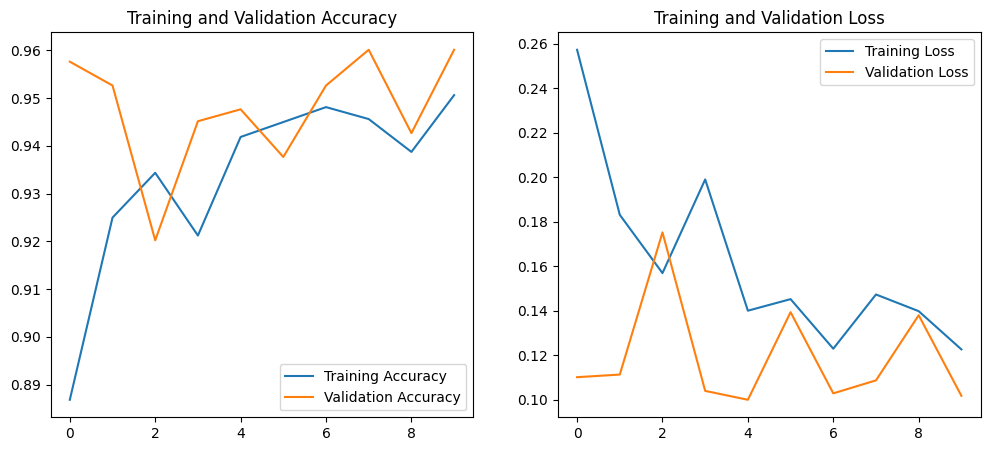

In [ ]:
import matplotlib.pyplot as plt

# Plot Training and Validation metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()